# Task 2A - 05 Modelling: an ablation ladder
Start from the simplest explainable model and add **one idea at a time**, keeping an idea only if it improves MAE, RMSE and WAPE on the rolling backtest. (Rule agreed with the team: ridge first; boosting only if it helps consistently.)

Model family (all forecast **mean daily volume on operating days**, then sum to weeks):
- `DailyRidgeGB`: ridge on log daily volume, lognormal-mean back-transform (so forecasts are means), optional pooled depots, optional boosting on ridge residuals;
- `TechRidge`: small linear model for the sparse, noisy Tech series.

In [1]:
import sys, warnings; warnings.filterwarnings('ignore')
sys.path.append('../../tools/task2a')
import numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, json
from task2a_common import *
from task2a_features import *
from task2a_models import *
from task2a_validation import *
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 50); pd.set_option('display.max_rows', 100)
plt.rcParams.update({'figure.dpi': 90, 'axes.grid': True, 'grid.alpha': .25})
for d in (INTERIM, METRICS, FIGURES): d.mkdir(parents=True, exist_ok=True)
o, cal = load_orders(); cal2 = enrich_calendar(cal); panel = build_panel(o, cal2)


## 1. Fresh and Style ladder

In [2]:
NY = ('r_new_year',)
ladder = [
    ('A0 per-depot ridge, no trend',             lambda: DailyRidgeGB((), pooled=False, gb=False, trend='none')),
    ('A1 + damped trend',                         lambda: DailyRidgeGB((), pooled=False, gb=False, trend='damped')),
    ('A2 + New Year ramp',                        lambda: DailyRidgeGB(NY, pooled=False, gb=False)),
    ('A3 + a ramp per festival (per-depot)',      lambda: DailyRidgeGB(PROD_EXTRA, pooled=False, gb=False)),
    ('A4 + pooled depots',                        lambda: DailyRidgeGB(PROD_EXTRA, pooled=True, gb=False)),
    ('A5 + residual boosting (production Fresh)', lambda: DailyRidgeGB(PROD_EXTRA, pooled=True, gb=True)),
]
style_final = ('A6 Style: drop the trend (production Style)', lambda: DailyRidgeGB(PROD_EXTRA, pooled=True, gb=True, trend='none'))
res = [backtest(panel, b, mk, name=n) for b in ('Fresh', 'Style') for n, mk in ladder]
res.append(backtest(panel, 'Style', style_final[1], name=style_final[0]))
bt = pd.concat(res); bt.to_pickle(METRICS / 'task2a_ladder_weeks.pkl')
sl = summarize(bt); sl.to_csv(METRICS / 'task2a_ladder.csv', index=False)
sl.sort_values(['brand', 'model'])

,model,brand,n,MAE,RMSE,WAPE,bias
0,"A0 per-depot ridge, no trend",Fresh,680.0,38.3838,54.2952,0.0517,-0.0433
2,A1 + damped trend,Fresh,680.0,29.7397,43.4952,0.0400,-0.0054
4,A2 + New Year ramp,Fresh,680.0,27.0600,36.6550,0.0364,-0.0047
6,A3 + a ramp per festival (per-depot),Fresh,680.0,24.1476,32.5189,0.0325,-0.0087
8,A4 + pooled depots,Fresh,680.0,24.2055,32.3123,0.0326,-0.0088
10,A5 + residual boosting (production Fresh),Fresh,680.0,23.6448,32.2244,0.0318,-0.0122
1,"A0 per-depot ridge, no trend",Style,680.0,10.3508,16.8526,0.0925,-0.0273
3,A1 + damped trend,Style,680.0,10.5615,16.9563,0.0944,-0.0251
5,A2 + New Year ramp,Style,680.0,10.1224,16.4159,0.0905,-0.0238
7,A3 + a ramp per festival (per-depot),Style,680.0,9.4336,15.7833,0.0843,-0.0336


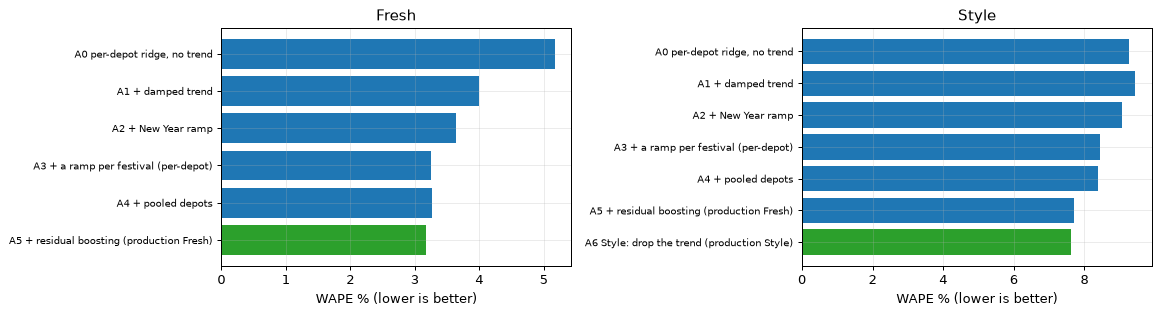

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(13, 3.6))
for a, b in zip(axs, ('Fresh', 'Style')):
    g = sl[sl.brand == b].sort_values('model').reset_index(drop=True)
    a.barh(range(len(g)), g.WAPE * 100, color=['C0'] * (len(g) - 1) + ['C2']); a.set_yticks(range(len(g))); a.set_yticklabels([x[:44] for x in g.model], fontsize=8)
    a.invert_yaxis(); a.set_xlabel('WAPE % (lower is better)'); a.set_title(b)
plt.tight_layout(); plt.savefig(FIGURES / '05_ladder.png'); plt.show()

**Reading (Fresh WAPE 5.2% -> 3.2%, Style 9.3% -> 7.6%).**
- **Trend** is the first big win for Fresh (5.2% -> 4.0%): demand grows a few % a year and a trend-free model is biased low (-4.3%).
- **A New Year ramp** (4.0% -> 3.6%) and then **a ramp per festival** (3.6% -> 3.25%) are the next biggest steps: festivals differ a lot in size and one shared ramp averages them.
- **Pooling the depots** is roughly neutral for Fresh (3.25% vs 3.26%) and a small gain for Style (8.43% -> 8.37%). We keep it because it gives one model per brand with equal or better accuracy, and it is what the boosting stage builds on - but it is *not* a source of accuracy and we do not claim it is.
- **Residual boosting** adds a further gain (Fresh 3.26% -> 3.18%, Style 8.4% -> 7.7%).
- **Style without a trend** is best (A6): its demand shows no reliable growth and extrapolating it only adds error; Fresh keeps the damped trend.

## 2. Is boosting worth its complexity? (consistency across origins)
Agreed rule: keep boosting only if it improves out-of-time accuracy consistently, not just on average.

In [4]:
a = bt[bt.model.str.startswith('A4')].groupby(['brand', 'cut']).apply(lambda g: (g.pred - g.actual).abs().sum() / g.actual.sum()).rename('ridge')
b_ = bt[bt.model.str.startswith('A5')].groupby(['brand', 'cut']).apply(lambda g: (g.pred - g.actual).abs().sum() / g.actual.sum()).rename('ridge+gb')
w = pd.concat([a, b_], axis=1)
print('origins where boosting is better:'); print((w['ridge+gb'] < w['ridge']).groupby('brand').agg(['sum', 'count']))
print('\nmedian WAPE across origins:'); print(w.groupby('brand').median().round(4))

origins where boosting is better:
       sum  count
brand            
Fresh   21     34
Style   25     34

median WAPE across origins:
        ridge  ridge+gb
brand                  
Fresh  0.0317    0.0280
Style  0.0842    0.0788


**Reading (boosting).** Boosting is better in 21 of 34 origins for Fresh and 25 of 34 for Style, and improves the *median* origin (Fresh 3.17% -> 2.80%, Style 8.4% -> 7.9%). It is clearly better in festival windows (05b) and sometimes slightly worse in calm ones - a real but not universal gain, so it is kept as a small, shallow residual learner (depth 3, 60 trees) on top of the explainable ridge, which stays the backbone.

## 3. Tech ladder

In [5]:
tl = [
    ('T0 constant: last 52 weeks mean',   lambda: NaiveRecent(52)),
    ('T1 weekday ridge',                  lambda: TechRidge(cols=DOW, trend=False)),
    ('T2 + payday + ramp',                lambda: TechRidge(trend=False)),
    ('T3 + damped trend (= production)',  lambda: TechRidge(trend=True)),
]
bt_t = pd.concat([backtest(panel, 'Tech', mk, name=n) for n, mk in tl]); bt_t.to_pickle(METRICS / 'task2a_tech_ladder_weeks.pkl')
st = summarize(bt_t); st.to_csv(METRICS / 'task2a_tech_ladder.csv', index=False); st

,model,brand,n,MAE,RMSE,WAPE,bias
0,T0 constant: last 52 weeks mean,Tech,680.0,7.8546,9.5231,0.3013,-0.0507
1,T1 weekday ridge,Tech,680.0,7.7828,9.4614,0.2985,-0.0586
2,T2 + payday + ramp,Tech,680.0,7.6545,9.4163,0.2936,-0.0591
3,T3 + damped trend (= production),Tech,680.0,7.6673,9.3555,0.2941,-0.0344


**Reading.** Tech is mostly irreducible noise (a few large single-item orders), so the best model is only about 2.5% better in WAPE than a constant (30.1% -> 29.4%): the weekday schedule and payday help a little, a trend reduces bias. We tried Poisson GLMs, Poisson boosting, quarter dummies and shrinkage blends in exploration - none beat this small ridge, so complexity was not added.

## 4. Chilled volume: share of total vs direct model

In [6]:
tot = lambda: make_model('Fresh')
cf = [
    ('share: total forecast x depot chilled share', lambda: ChilledModel(tot, 'share')),
    ('direct: same architecture fitted on chilled',  lambda: ChilledModel(tot, 'direct')),
    ('blend 30% direct + 70% share',                  lambda: ChilledModel(tot, 'blend', 0.3)),
    ('blend 50/50 (production)',                      lambda: ChilledModel(tot, 'blend', 0.5)),
]
bt_c = pd.concat([backtest(panel, 'Fresh', mk, name=n, target='ch') for n, mk in cf])
bt_c.to_pickle(METRICS / 'task2a_chilled_weeks.pkl'); sc = summarize(bt_c); sc.to_csv(METRICS / 'task2a_chilled.csv', index=False)
print(sc.to_string()); festival_split(bt_c).pivot_table(index='model', columns='bucket', values='WAPE').round(4)

                                         model  brand      n      MAE     RMSE    WAPE    bias
0                 blend 30% direct + 70% share  Fresh  680.0   9.7803  13.0583  0.0361 -0.0091
1                     blend 50/50 (production)  Fresh  680.0   9.5966  12.8641  0.0354 -0.0122
2  direct: same architecture fitted on chilled  Fresh  680.0   9.7885  13.1797  0.0361 -0.0200
3  share: total forecast x depot chilled share  Fresh  680.0  10.4164  13.6743  0.0384 -0.0044


bucket,festival run-up weeks,other weeks
model,,
blend 30% direct + 70% share,0.0312,0.0369
blend 50/50 (production),0.0289,0.0364
direct: same architecture fitted on chilled,0.0276,0.0375
share: total forecast x depot chilled share,0.0369,0.0387


**Reading.** Chilled has its own run-up dynamics, so a direct model beats the plain share; the share is more stable outside festival weeks. A 50/50 blend is best on all three metrics. All variants are capped at the total forecast (`chilled <= total`). Style and Tech chilled are exactly 0.

## Production configuration
- **Fresh:** pooled `DailyRidgeGB` (ramp per festival, damped trend phi 0.9, residual boosting depth 3).
- **Style:** same, **without** a trend (rolling backtest prefers it on every metric, see 05c).
- **Tech:** `TechRidge` (weekday, payday, ramp, damped trend).
- **Chilled (Fresh):** 50/50 blend of a direct chilled model and total x chilled share.

Hyper-parameter sensitivity and stress tests follow in 05c; error analysis in 05b.